# cloudposterior: Eight Schools Demo

Run PyMC MCMC sampling on Modal cloud VMs with a one-line API change.

In [9]:
import numpy as np
import pymc as pm
import arviz as az

import cloudposterior as pd

## Data

The classic Eight Schools dataset from Rubin (1981). Eight schools administered coaching programs, and the effects (with standard errors) were estimated for each.

In [10]:
y = np.array([28, 8, -3, 7, -1, 1, 18, 12], dtype=np.float64)
sigma = np.array([15, 10, 16, 11, 9, 11, 10, 18], dtype=np.float64)
schools = ["A", "B", "C", "D", "E", "F", "G", "H"]

## Model

Non-centered parameterization of the hierarchical model to reduce divergences.

In [11]:
with pm.Model(coords={"school": schools}) as eight_schools:
    # Hyperpriors
    mu = pm.Normal("mu", mu=0, sigma=5)
    tau = pm.HalfCauchy("tau", beta=5)

    # Non-centered parameterization
    theta_raw = pm.Normal("theta_raw", mu=0, sigma=1, dims="school")
    theta = pm.Deterministic("theta", mu + tau * theta_raw, dims="school")

    # Likelihood
    pm.Normal("obs", mu=theta, sigma=sigma, observed=y, dims="school")

## Sample remotely on Modal

Wrap the model with `pd.wrap()`. Caching is on by default; opt into remote execution with `remote=True`.

In [12]:
with pd.wrap(eight_schools, remote=True, notify=True):
    idata = pm.sample(draws=2000, tune=1000, chains=4)

## Diagnostics

In [13]:
az.summary(idata, var_names=["mu", "tau", "theta"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,4.436,3.292,-1.870,10.567,0.035,0.039,8724.0,4594.0,1.0
tau,3.599,3.211,0.003,9.277,0.043,0.062,4790.0,3245.0,1.0
theta[A],6.150,5.368,-3.169,16.760,0.062,0.083,8186.0,5785.0,1.0
theta[B],5.008,4.668,-3.608,14.223,0.048,0.060,9766.0,6235.0,1.0
theta[C],3.935,5.190,-5.710,13.969,0.058,0.078,8489.0,5884.0,1.0
theta[D],4.742,4.857,-4.063,14.349,0.051,0.071,9468.0,6163.0,1.0
theta[E],3.635,4.691,-5.499,12.147,0.053,0.063,8303.0,5599.0,1.0
theta[F],4.130,4.867,-4.905,13.500,0.052,0.065,9089.0,5796.0,1.0
theta[G],6.436,5.189,-2.794,16.590,0.058,0.070,8434.0,5445.0,1.0
theta[H],4.908,5.286,-5.001,14.981,0.060,0.079,8229.0,6250.0,1.0


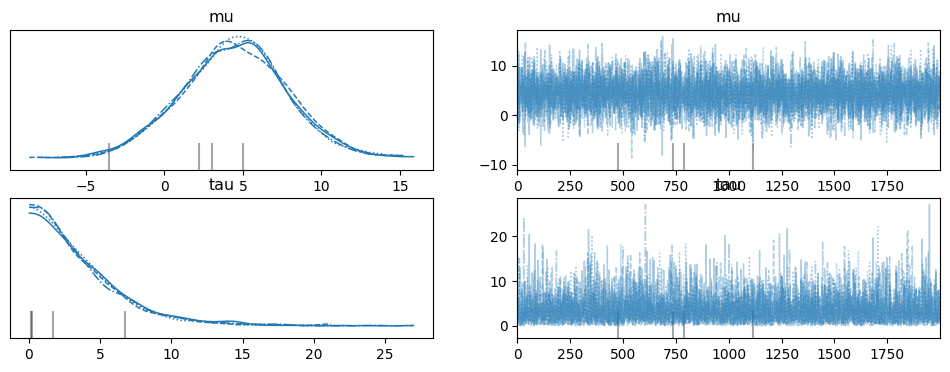

In [14]:
az.plot_trace(idata, var_names=["mu", "tau"]);

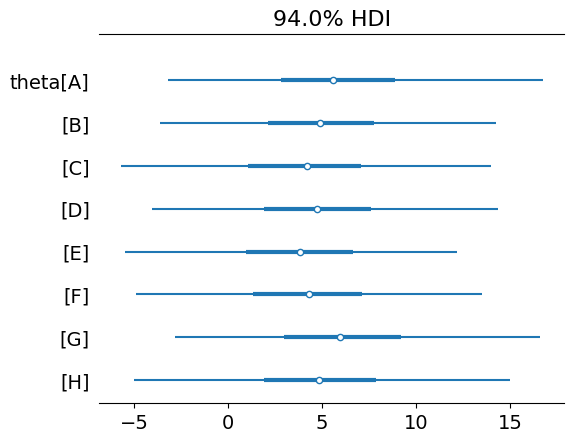

In [15]:
az.plot_forest(idata, var_names=["theta"], combined=True, hdi_prob=0.94);

## Compare: local vs remote

Run the same model locally to verify the remote results are statistically equivalent.

In [16]:
with eight_schools:
    idata_local = pm.sample(draws=2000, tune=1000, chains=4)

az.summary(idata_local, var_names=["mu", "tau", "theta"])

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, tau, theta_raw]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.
There were 7 divergences after tuning. Increase `target_accept` or reparameterize.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu,4.402,3.259,-1.625,10.481,0.035,0.040,8826.0,4672.0,1.0
tau,3.605,3.196,0.001,9.148,0.044,0.070,4671.0,3872.0,1.0
theta[A],6.298,5.699,-4.163,17.174,0.069,0.114,7966.0,5906.0,1.0
theta[B],4.966,4.639,-4.051,13.905,0.050,0.062,9035.0,6233.0,1.0
theta[C],3.881,5.213,-5.897,13.866,0.058,0.074,8323.0,5645.0,1.0
theta[D],4.676,4.791,-5.049,13.498,0.052,0.063,8879.0,5639.0,1.0
theta[E],3.592,4.570,-5.048,12.436,0.049,0.059,9304.0,5685.0,1.0
theta[F],4.114,4.868,-5.638,12.770,0.051,0.072,9889.0,6038.0,1.0
theta[G],6.294,5.070,-3.040,15.843,0.059,0.074,7816.0,5672.0,1.0
theta[H],4.916,5.245,-5.009,15.205,0.058,0.079,8709.0,5472.0,1.0
